In [1]:
import numpy as np

from sklearn.datasets import load_breast_cancer
from sklearn.datasets import fetch_california_housing

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import (classification_report,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_absolute_error,
    mean_squared_error,
    r2_score)

import matplotlib.pyplot as plt

# Parte 1: classificando tumores com k-vizinhos

In [2]:
features,alvo = load_breast_cancer(return_X_y=True)

valores_k = [1,3,5,7]

historico = []

modelo_campeao = None
maior_acuracia = 0
escala_campea = ""
k_campeao = None
teste_campeao = None

In [3]:
# divisão dos dados originais em treino e teste
features_treino, features_teste, alvo_treino, alvo_teste = train_test_split(features,alvo, test_size=0.2, random_state=42)

In [4]:
# atributos na escala em que vieram
print("ESCALA ORIGINAL")
for n_vizinhos in valores_k:
    classificador = KNeighborsClassifier(n_neighbors=n_vizinhos)
    classificador.fit(features_treino, alvo_treino)

    # saídas do classificador nos dois conjuntos
    previsao_treino = classificador.predict(features_treino)
    previsao_teste = classificador.predict(features_teste)

    # proporção de acertos
    acuracia_treino = accuracy_score(alvo_treino, previsao_treino)
    acuracia_teste = accuracy_score(alvo_teste, previsao_teste)

    print(f"\n----- {n_vizinhos} vizinho(s) -----")

    print(f"Acertos no treino: {acuracia_treino:.4f}")
    print(f"Acertos no teste:  {acuracia_teste:.4f}")

    # precisão, recall e f1 por classe (dados de teste)
    print("\nMétricas por classe:")
    print(classification_report(alvo_teste, previsao_teste))

    pontuacao = classificador.score(features_teste, alvo_teste)
    print(f"Vizinhos = {n_vizinhos}: {pontuacao:.4f}")

    historico.append({
        "Vizinhos": n_vizinhos,
        "Escala": "Dados brutos",
        "Acc treino": acuracia_treino,
        "Acc teste": acuracia_teste
    })

    if acuracia_teste > maior_acuracia:
        maior_acuracia = acuracia_teste
        modelo_campeao = classificador
        escala_campea = "Dados brutos"
        k_campeao = n_vizinhos
        teste_campeao = features_teste

ESCALA ORIGINAL

----- 1 vizinho(s) -----
Acertos no treino: 1.0000
Acertos no teste:  0.9298

Métricas por classe:
              precision    recall  f1-score   support

           0       0.95      0.86      0.90        43
           1       0.92      0.97      0.95        71

    accuracy                           0.93       114
   macro avg       0.93      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114

Vizinhos = 1: 0.9298

----- 3 vizinho(s) -----
Acertos no treino: 0.9495
Acertos no teste:  0.9298

Métricas por classe:
              precision    recall  f1-score   support

           0       0.93      0.88      0.90        43
           1       0.93      0.96      0.94        71

    accuracy                           0.93       114
   macro avg       0.93      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114

Vizinhos = 3: 0.9298

----- 5 vizinho(s) -----
Acertos no treino: 0.9407
Acertos no teste:  0.9561

Métricas 

In [5]:
normalizador = MinMaxScaler()
padronizador = StandardScaler()

treino_normalizado = normalizador.fit_transform(features_treino)
teste_normalizado = normalizador.transform(features_teste)

treino_padronizado = padronizador.fit_transform(features_treino)
teste_padronizado = padronizador.transform(features_teste)

In [6]:
# atributos reescalados para o intervalo [0, 1]
print("ESCALA MIN-MAX")
for n_vizinhos in valores_k:
    classificador = KNeighborsClassifier(n_neighbors=n_vizinhos)
    classificador.fit(treino_normalizado, alvo_treino)

    # saídas do classificador nos dois conjuntos
    previsao_treino = classificador.predict(treino_normalizado)
    previsao_teste = classificador.predict(teste_normalizado)

    # proporção de acertos
    acuracia_treino = accuracy_score(alvo_treino, previsao_treino)
    acuracia_teste = accuracy_score(alvo_teste, previsao_teste)

    print(f"\n----- {n_vizinhos} vizinho(s) -----")

    print(f"Acertos no treino: {acuracia_treino:.4f}")
    print(f"Acertos no teste:  {acuracia_teste:.4f}")

    # precisão, recall e f1 por classe (dados de teste)
    print("\nMétricas por classe:")
    print(classification_report(alvo_teste, previsao_teste))

    pontuacao = classificador.score(teste_normalizado, alvo_teste)
    print(f"Vizinhos = {n_vizinhos}: {pontuacao:.4f}")

    historico.append({
        "Vizinhos": n_vizinhos,
        "Escala": "Reescalado (min-max)",
        "Acc treino": acuracia_treino,
        "Acc teste": acuracia_teste
    })

    # atualiza o campeão se este for superior
    if acuracia_teste > maior_acuracia:
        maior_acuracia = acuracia_teste
        modelo_campeao = classificador
        escala_campea = "Min-max"
        k_campeao = n_vizinhos
        teste_campeao = teste_normalizado

ESCALA MIN-MAX

----- 1 vizinho(s) -----
Acertos no treino: 1.0000
Acertos no teste:  0.9561

Métricas por classe:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94        43
           1       0.97      0.96      0.96        71

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114

Vizinhos = 1: 0.9561

----- 3 vizinho(s) -----
Acertos no treino: 0.9868
Acertos no teste:  0.9649

Métricas por classe:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        43
           1       0.97      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114

Vizinhos = 3: 0.9649

----- 5 vizinho(s) -----
Acertos no treino: 0.9758
Acertos no teste:  0.9649

Métricas p

In [7]:
# atributos com média 0 e desvio 1
print("ESCALA Z-SCORE")
for n_vizinhos in valores_k:
    classificador = KNeighborsClassifier(n_neighbors=n_vizinhos)
    classificador.fit(treino_padronizado, alvo_treino)

    # saídas do classificador nos dois conjuntos
    previsao_treino = classificador.predict(treino_padronizado)
    previsao_teste = classificador.predict(teste_padronizado)

    # proporção de acertos
    acuracia_treino = accuracy_score(alvo_treino, previsao_treino)
    acuracia_teste = accuracy_score(alvo_teste, previsao_teste)

    print(f"\n----- {n_vizinhos} vizinho(s) -----")

    print(f"Acertos no treino: {acuracia_treino:.4f}")
    print(f"Acertos no teste:  {acuracia_teste:.4f}")

    # precisão, recall e f1 por classe (dados de teste)
    print("\nMétricas por classe:")
    print(classification_report(alvo_teste, previsao_teste))

    pontuacao = classificador.score(teste_padronizado, alvo_teste)
    print(f"Vizinhos = {n_vizinhos}: {pontuacao:.4f}")

    historico.append({
        "Vizinhos": n_vizinhos,
        "Escala": "Reescalado (z-score)",
        "Acc treino": acuracia_treino,
        "Acc teste": acuracia_teste
    })

    # atualiza o campeão se este for superior
    if acuracia_teste > maior_acuracia:
        maior_acuracia = acuracia_teste
        modelo_campeao = classificador
        escala_campea = "Z-score"
        k_campeao = n_vizinhos
        teste_campeao = teste_padronizado

ESCALA Z-SCORE

----- 1 vizinho(s) -----
Acertos no treino: 1.0000
Acertos no teste:  0.9386

Métricas por classe:
              precision    recall  f1-score   support

           0       0.93      0.91      0.92        43
           1       0.94      0.96      0.95        71

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114

Vizinhos = 1: 0.9386

----- 3 vizinho(s) -----
Acertos no treino: 0.9846
Acertos no teste:  0.9474

Métricas por classe:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114

Vizinhos = 3: 0.9474

----- 5 vizinho(s) -----
Acertos no treino: 0.9802
Acertos no teste:  0.9474

Métricas p


RESUMO DOS TESTES
viz= 1 | Dados brutos              | treino: 1.0000 | teste: 0.9298
viz= 3 | Dados brutos              | treino: 0.9495 | teste: 0.9298
viz= 5 | Dados brutos              | treino: 0.9407 | teste: 0.9561
viz= 7 | Dados brutos              | treino: 0.9407 | teste: 0.9561
viz= 1 | Reescalado (min-max)      | treino: 1.0000 | teste: 0.9561
viz= 3 | Reescalado (min-max)      | treino: 0.9868 | teste: 0.9649
viz= 5 | Reescalado (min-max)      | treino: 0.9758 | teste: 0.9649
viz= 7 | Reescalado (min-max)      | treino: 0.9714 | teste: 0.9649
viz= 1 | Reescalado (z-score)      | treino: 1.0000 | teste: 0.9386
viz= 3 | Reescalado (z-score)      | treino: 0.9846 | teste: 0.9474
viz= 5 | Reescalado (z-score)      | treino: 0.9802 | teste: 0.9474
viz= 7 | Reescalado (z-score)      | treino: 0.9692 | teste: 0.9474

Configuração vencedora:
Vizinhos = 3
Escala = Min-max
Acertos no teste = 0.9649

DESEMPENHO POR CLASSE
              precision    recall  f1-score   support

     m

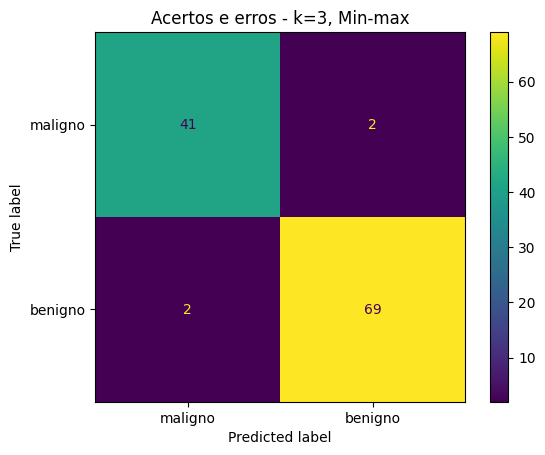

In [8]:
print("\nRESUMO DOS TESTES")

for registro in historico:

    print(
        f"viz={registro['Vizinhos']:>2} | "
        f"{registro['Escala']:<25} | "
        f"treino: {registro['Acc treino']:.4f} | "
        f"teste: {registro['Acc teste']:.4f}"
    )


print("\nConfiguração vencedora:")
print(f"Vizinhos = {k_campeao}")
print(f"Escala = {escala_campea}")
print(f"Acertos no teste = {maior_acuracia:.4f}")


previsao_final = modelo_campeao.predict(teste_campeao)

print("\nDESEMPENHO POR CLASSE")

print(
    classification_report(
        alvo_teste,
        previsao_final,
        target_names=["maligno", "benigno"]
    )
)


# contagem de acertos e erros por classe
matriz = confusion_matrix(alvo_teste, previsao_final)

print("\nACERTOS E ERROS POR CLASSE")
print(matriz)

grafico_matriz = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=["maligno", "benigno"]
)

grafico_matriz.plot()

plt.title(
    f"Acertos e erros - k={k_campeao}, {escala_campea}"
)

plt.show()

# Parte 2: prevendo preços de casas

In [9]:
features,alvo = fetch_california_housing(return_X_y=True)

In [10]:
features_treino, features_teste, alvo_treino, alvo_teste = train_test_split(features, alvo, test_size=0.2, random_state=42)

In [11]:
# z-score
escalador_zscore = StandardScaler()

treino_zscore = escalador_zscore.fit_transform(features_treino)
teste_zscore = escalador_zscore.transform(features_teste)


# min-max
normalizador = MinMaxScaler()

treino_minmax = normalizador.fit_transform(features_treino)
teste_minmax = normalizador.transform(features_teste)

In [12]:
def medir_desempenho(estimador, features_treino, features_teste, alvo_treino, alvo_teste):

    estimador.fit(features_treino, alvo_treino)

    saida_treino = estimador.predict(features_treino)
    saida_teste = estimador.predict(features_teste)

    # erros no conjunto de treino
    erro_abs_treino = mean_absolute_error(alvo_treino, saida_treino)
    erro_quad_treino = mean_squared_error(alvo_treino, saida_treino)
    raiz_erro_treino = np.sqrt(erro_quad_treino)
    coef_det_treino = r2_score(alvo_treino, saida_treino)

    # erros no conjunto de teste
    erro_abs_teste = mean_absolute_error(alvo_teste, saida_teste)
    erro_quad_teste = mean_squared_error(alvo_teste, saida_teste)
    raiz_erro_teste = np.sqrt(erro_quad_teste)
    coef_det_teste = r2_score(alvo_teste, saida_teste)

    return {
        "EAM treino": erro_abs_treino,
        "EQM treino": erro_quad_treino,
        "REQM treino": raiz_erro_treino,
        "R² treino": coef_det_treino,

        "EAM teste": erro_abs_teste,
        "EQM teste": erro_quad_teste,
        "REQM teste": raiz_erro_teste,
        "R² teste": coef_det_teste
    }

In [13]:
registros_linear = []

# escala original
registro = medir_desempenho(
    LinearRegression(),
    features_treino,
    features_teste,
    alvo_treino,
    alvo_teste
)

registro["Algoritmo"] = "Reg. linear"
registro["Escala"] = "Dados brutos"

registros_linear.append(registro)


# atributos com média 0 e desvio 1
registro = medir_desempenho(
    LinearRegression(),
    treino_zscore,
    teste_zscore,
    alvo_treino,
    alvo_teste
)

registro["Algoritmo"] = "Reg. linear"
registro["Escala"] = "Z-score"

registros_linear.append(registro)


# atributos reescalados para o intervalo [0, 1]
registro = medir_desempenho(
    LinearRegression(),
    treino_minmax,
    teste_minmax,
    alvo_treino,
    alvo_teste
)

registro["Algoritmo"] = "Reg. linear"
registro["Escala"] = "Min-max"

registros_linear.append(registro)

print("Regressão linear: concluída")

# ========== KNN ==========

registros_knn = []
valores_k = [3, 5, 7, 10, 15, 20]

for n_vizinhos in valores_k:

    estimador = KNeighborsRegressor(
        n_neighbors=n_vizinhos,
        weights="distance"
    )

    registro = medir_desempenho(
        estimador,
        features_treino,
        features_teste,
        alvo_treino,
        alvo_teste
    )

    registro["Algoritmo"] = f"Vizinhos k={n_vizinhos}"
    registro["Escala"] = "Dados Brutos"

    registros_knn.append(registro)


    estimador = KNeighborsRegressor(
        n_neighbors=n_vizinhos,
        weights="distance"
    )

    registro = medir_desempenho(
        estimador,
        treino_zscore,
        teste_zscore,
        alvo_treino,
        alvo_teste
    )

    registro["Algoritmo"] = f"Vizinhos k={n_vizinhos}"
    registro["Escala"] = "Z-score"

    registros_knn.append(registro)


    estimador = KNeighborsRegressor(
        n_neighbors=n_vizinhos,
        weights="distance"
    )

    registro = medir_desempenho(
        estimador,
        treino_minmax,
        teste_minmax,
        alvo_treino,
        alvo_teste
    )

    registro["Algoritmo"] = f"Vizinhos k={n_vizinhos}"
    registro["Escala"] = "Min-max"

    registros_knn.append(registro)

print("Regressão por vizinhos: concluída")

Regressão linear: concluída
Regressão por vizinhos: concluída


In [14]:
import pandas as pd

historico = registros_linear + registros_knn
tabela = pd.DataFrame(historico)

        Algoritmo        Escala  REQM treino  REQM teste  R² treino  R² teste  \
0     Reg. linear  Dados brutos       0.7197      0.7456     0.6126    0.5758   
1     Reg. linear       Z-score       0.7197      0.7456     0.6126    0.5758   
2     Reg. linear       Min-max       0.7197      0.7456     0.6126    0.5758   
3    Vizinhos k=3  Dados Brutos       0.0000      1.0697     1.0000    0.1268   
4    Vizinhos k=3       Z-score       0.0000      0.6827     1.0000    0.6443   
5    Vizinhos k=3       Min-max       0.0000      0.6548     1.0000    0.6728   
6    Vizinhos k=5  Dados Brutos       0.0000      1.0418     1.0000    0.1718   
7    Vizinhos k=5       Z-score       0.0000      0.6557     1.0000    0.6719   
8    Vizinhos k=5       Min-max       0.0000      0.6327     1.0000    0.6945   
9    Vizinhos k=7  Dados Brutos       0.0000      1.0339     1.0000    0.1842   
10   Vizinhos k=7       Z-score       0.0000      0.6509     1.0000    0.6767   
11   Vizinhos k=7       Min-

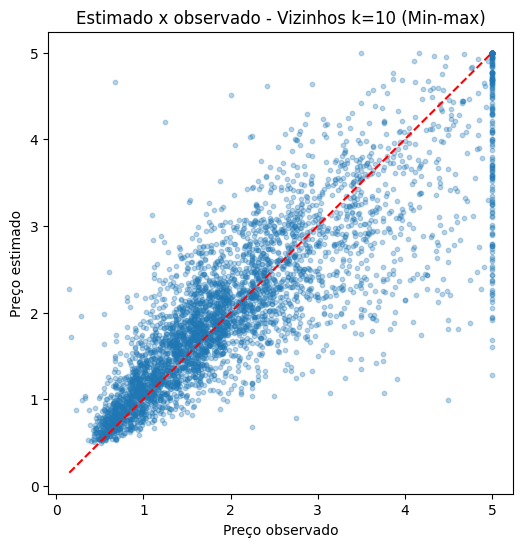

In [15]:
# diferença de R² entre treino e teste: quanto maior, mais o modelo decorou os dados
tabela["Queda de R²"] = tabela["R² treino"] - tabela["R² teste"]

print(tabela[["Algoritmo", "Escala", "REQM treino", "REQM teste",
                     "R² treino", "R² teste", "Queda de R²"]].round(4))

# seleciona a linha com o R² de teste mais alto
vencedor = tabela.loc[tabela["R² teste"].idxmax()]
print("\nMAIOR R² NO TESTE:")
print(vencedor[["Algoritmo", "Escala", "EAM teste", "REQM teste",
              "R² treino", "R² teste", "Queda de R²"]])

# treina de novo a configuração selecionada e compara previsões com valores verdadeiros
conjuntos = {
    "Dados brutos": (features_treino, features_teste),
    "Z-score": (treino_zscore, teste_zscore),
    "Min-max": (treino_minmax, teste_minmax),
}
entrada_treino, entrada_teste = conjuntos[vencedor["Escala"]]

if vencedor["Algoritmo"] == "Reg. linear":
    estimador = LinearRegression()
else:
    n_vizinhos = int(vencedor["Algoritmo"].split("=")[1])
    estimador = KNeighborsRegressor(n_neighbors=n_vizinhos, weights="distance")

estimador.fit(entrada_treino, alvo_treino)
estimativas = estimador.predict(entrada_teste)

plt.figure(figsize=(6, 6))
plt.scatter(alvo_teste, estimativas, alpha=0.3, s=10)
plt.plot([alvo_teste.min(), alvo_teste.max()], [alvo_teste.min(), alvo_teste.max()], "r--")
plt.xlabel("Preço observado")
plt.ylabel("Preço estimado")
plt.title(f"Estimado x observado - {vencedor['Algoritmo']} ({vencedor['Escala']})")
plt.show()